# 18 — v03b Validation (CMEMS-forced wave coupling)

Validation of the D-Flow FM + SWAN coupled run (v03b) that uses time-varying
CMEMS wave boundaries, replacing the constant JONSWAP placeholders of v03a.

**Sections:**
1. Setup + partition merge
2. Sanity check — physical ranges of key variables
3. Water level validation vs in-situ at 3 obs points (BocaNord, BocaSud, AltaVilaEst) + comparison with v03a baseline
4. Wave fields sanity — no in-situ Hs/Tp, so plausibility checks only
5. v03a → v03b delta — did wave coupling change hydrodynamics at obs points?

**v03a baseline metrics** (from `data/processed/validation_metrics_v03a.csv`):
| Station | RMSE | Bias | Corr | Willmott |
|---|---|---|---|---|
| BocaNord | 0.067 | -0.014 | 0.935 | 0.85 |
| BocaSud | 0.101 | -0.082 | 0.928 | 0.68 |
| AltaVilaEst | 0.080 | +0.007 | 0.825 | 0.79 |

## 1. Setup + merge partitions

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

project_root = Path.cwd().parent
v03b_dir = project_root / 'model' / 'dflowfm_v03b'
out_dir  = v03b_dir / 'DFM_OUTPUT_Stagnone_dxy01_15m'
fig_dir  = project_root / 'figures'
proc_dir = project_root / 'data' / 'processed'
insitu_dir = proc_dir

# v03a baseline metrics for side-by-side comparison
v03a_metrics = pd.read_csv(proc_dir / 'validation_metrics_v03a.csv').set_index('Station')
print('v03a baseline:'); print(v03a_metrics.round(3))

v03a baseline:
              RMSE   Bias   Corr  Willmott_d  Std_obs  Std_mod
Station                                                       
BocaNord     0.067 -0.014  0.935       0.855    0.059    0.117
BocaSud      0.101 -0.082  0.928       0.679    0.053    0.104
AltaVilaEst  0.080  0.007  0.825       0.792    0.059    0.120


In [2]:
# --- Merge his.nc across partitions ---
# In FM MPI runs, each partition writes a his.nc but only stations assigned
# to that partition have valid data. Merge by picking values from partitions
# where they are non-missing.
import re
his_files = sorted(out_dir.glob('Stagnone_dxy01_15m_*_his.nc'))
print(f'Partitions: {len(his_files)}')

# Read station metadata from partition 0 and sanity-check
ds_his_0 = xr.open_dataset(his_files[0])
station_names = [s.decode().strip() if isinstance(s, bytes) else str(s).strip()
                 for s in ds_his_0.station_name.values]
print(f'Stations: {len(station_names)}')

# For time-series validation we mostly need waterlevel; each partition may have
# missing values (NaN/fill) at stations it does not own. Build a merged
# dataset by taking first non-NaN across partitions per station.
def merge_partition_hisvar(var):
    arrs = []
    for f in his_files:
        with xr.open_dataset(f) as ds_:
            if var not in ds_:
                continue
            arrs.append(ds_[var].load())
    if not arrs:
        return None
    # Stack along a new axis and pick the first finite value across partitions
    stacked = xr.concat(arrs, dim='part')
    merged = stacked.where(np.isfinite(stacked)).bfill(dim='part').isel(part=0)
    return merged

print('Merging variables...')
wl    = merge_partition_hisvar('waterlevel')
hwav  = merge_partition_hisvar('hwav')
twav  = merge_partition_hisvar('twav')
phiwv = merge_partition_hisvar('phiwav')
sal_v = merge_partition_hisvar('salinity')
uorb  = merge_partition_hisvar('uorb')
print('Done.')

Partitions: 1
Stations: 21
Merging variables...
Done.


## 2. Sanity check — physical ranges

In [3]:
def stats(name, da, expected):
    if da is None:
        print(f'{name}: NOT AVAILABLE'); return
    a = da.values
    finite = a[np.isfinite(a)]
    if finite.size == 0:
        print(f'{name}: all NaN'); return
    lo, hi = np.percentile(finite, [1, 99])
    print(f'{name:15s}  min={finite.min():>7.3f}  p1={lo:>7.3f}  '
          f'median={np.median(finite):>7.3f}  p99={hi:>7.3f}  max={finite.max():>7.3f}  '
          f'| expected {expected}')

print('Variable ranges across all stations, all times:')
stats('waterlevel', wl,    '~-0.5 to +0.5 m (tidal + surge)')
stats('hwav (Hs)',  hwav,  '~0.01 to 1.5 m (shallow lagoon + offshore CMEMS)')
stats('twav (Tp)',  twav,  '~2 to 8 s')
stats('phiwav',     phiwv, '0 to 360 deg')
stats('salinity',   sal_v, '~37 to 45 ppt (hypersaline lagoon)')
stats('uorb',       uorb,  '~0.01 to 0.5 m/s (near-bed orbital)')

Variable ranges across all stations, all times:
waterlevel       min= -0.291  p1= -0.207  median=  0.069  p99= 10.000  max= 10.000  | expected ~-0.5 to +0.5 m (tidal + surge)
hwav (Hs)        min=  0.000  p1=  0.000  median=  0.199  p99=  0.361  max=  0.361  | expected ~0.01 to 1.5 m (shallow lagoon + offshore CMEMS)
twav (Tp)        min=  0.000  p1=  0.919  median=  3.187  p99=  3.869  max=  3.869  | expected ~2 to 8 s
phiwav           min=262.044  p1=262.044  median=331.715  p99=343.442  max=343.442  | expected 0 to 360 deg
salinity         min= 37.034  p1= 37.618  median= 38.261  p99= 38.745  max= 38.831  | expected ~37 to 45 ppt (hypersaline lagoon)
uorb             min=  0.000  p1=  0.000  median=  0.000  p99=  0.217  max=  0.262  | expected ~0.01 to 0.5 m/s (near-bed orbital)


## 3. Water level validation vs in-situ

Load observation CSVs and compute metrics at BocaNord, BocaSud, AltaVilaEst.

In [4]:
def load_obs(name):
    path = insitu_dir / f'wl_{name}_10min_UTC.csv'
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.columns = ['wl_obs']
    return df

obs = {
    'BocaNord':    load_obs('BocaNord'),
    'BocaSud':     load_obs('BocaSud'),
    'AltaVilaEst': load_obs('AltavilaEst'),
}
for k, v in obs.items():
    print(f'{k}: {len(v)} samples, {v.index[0]} to {v.index[-1]}')

BocaNord: 1297 samples, 2025-06-30 23:00:00 to 2025-07-09 23:00:00
BocaSud: 1297 samples, 2025-06-30 23:00:00 to 2025-07-09 23:00:00
AltaVilaEst: 1297 samples, 2025-06-30 23:00:00 to 2025-07-09 23:00:00


In [5]:
def metrics(df, mod_col='wl_mod', obs_col='wl_obs'):
    d = df.dropna()
    m = d[mod_col].values
    o = d[obs_col].values
    bias = (m - o).mean()
    rmse = np.sqrt(((m - o) ** 2).mean())
    corr = np.corrcoef(m, o)[0, 1]
    om = o.mean()
    willmott = 1 - ((m - o) ** 2).sum() / ((np.abs(m - om) + np.abs(o - om)) ** 2).sum()
    return dict(RMSE=rmse, Bias=bias, Corr=corr, Willmott_d=willmott,
                Std_obs=o.std(), Std_mod=m.std())


# Detect station dimension name ('station' in most D-Flow FM versions, some use 'stations')
STATION_DIM = 'station' if 'station' in wl.dims else 'stations'
print(f"Station dim: '{STATION_DIM}'")


def station_idx(name):
    return station_names.index(name)


def at_station(da, name):
    """Select a station time series regardless of dim name."""
    return da.isel({STATION_DIM: station_idx(name)})


rows = []
for st in ['BocaNord', 'BocaSud', 'AltaVilaEst']:
    mod = at_station(wl, st).to_pandas().rename('wl_mod')
    # Drop the first 12 h of spin-up
    mod = mod[mod.index >= mod.index[0] + pd.Timedelta(hours=12)]
    df = pd.concat([mod, obs[st]['wl_obs']], axis=1).dropna()
    m = metrics(df)
    m['Station'] = st
    rows.append(m)

v03b_metrics = pd.DataFrame(rows).set_index('Station')
print('=== v03b water-level metrics ===')
print(v03b_metrics.round(3))

v03b_metrics.to_csv(proc_dir / 'validation_metrics_v03b.csv')
print(f'\nSaved: {proc_dir / "validation_metrics_v03b.csv"}')

Station dim: 'station'
=== v03b water-level metrics ===
              RMSE   Bias   Corr  Willmott_d  Std_obs  Std_mod
Station                                                       
BocaNord     0.067 -0.015  0.935       0.854    0.059    0.117
BocaSud      0.105 -0.086  0.927       0.665    0.053    0.105
AltaVilaEst  0.080  0.003  0.823       0.789    0.059    0.121

Saved: c:\Users\Unipa\Documents\StagnoneDT\data\processed\validation_metrics_v03b.csv


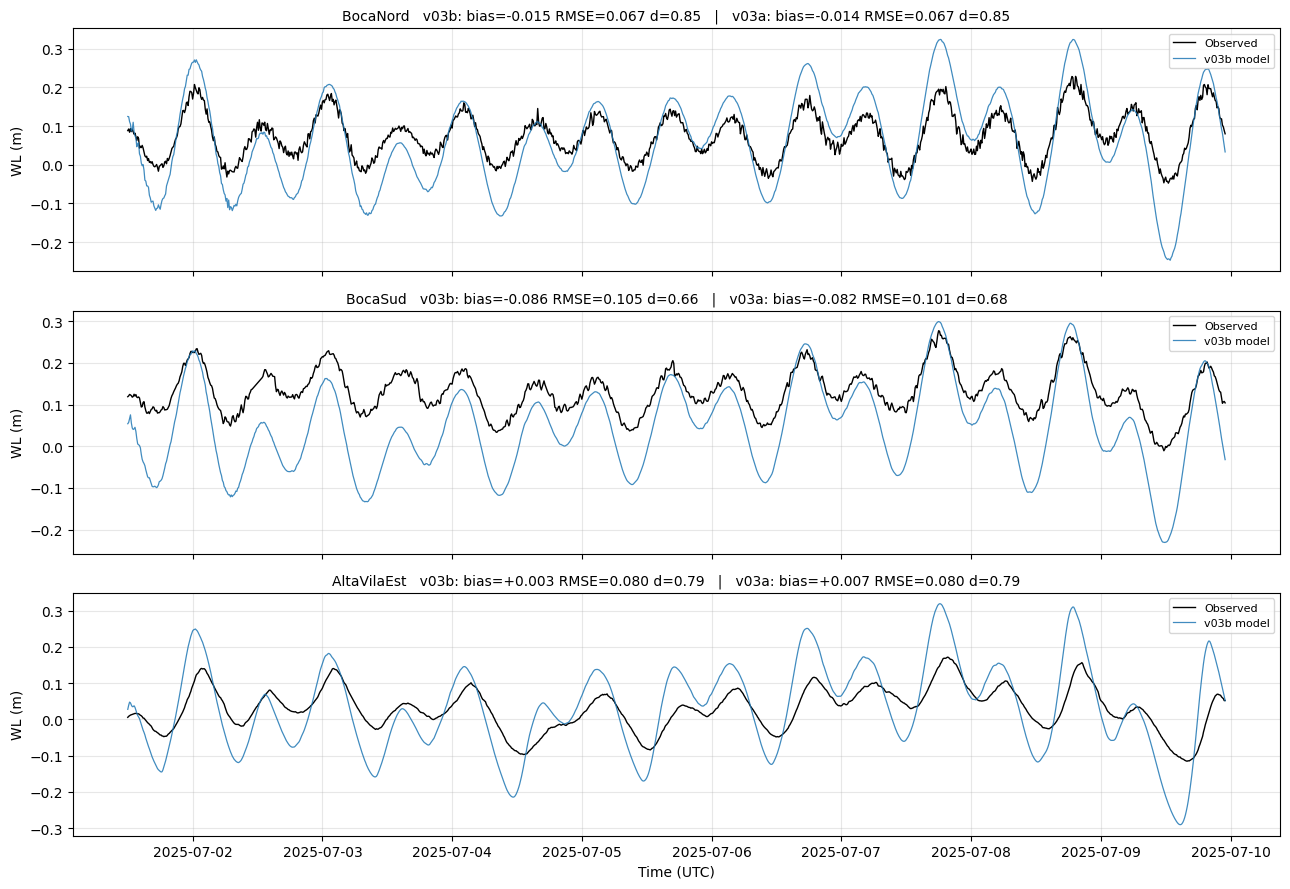

In [6]:
# Time-series plots: observed vs v03b at each obs point
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, st in zip(axes, ['BocaNord', 'BocaSud', 'AltaVilaEst']):
    mod = at_station(wl, st).to_pandas()
    mod = mod[mod.index >= mod.index[0] + pd.Timedelta(hours=12)]
    df = pd.concat([mod.rename('mod'), obs[st]['wl_obs']], axis=1).dropna()
    ax.plot(df.index, df['wl_obs'], 'k-', lw=1.0, label='Observed')
    ax.plot(df.index, df['mod'],    '-',  color='tab:blue', lw=0.9, alpha=0.85,
            label='v03b model')
    r = v03b_metrics.loc[st]
    r_a = v03a_metrics.loc[st]
    ax.set_title(f'{st}   v03b: bias={r.Bias:+.3f} RMSE={r.RMSE:.3f} d={r.Willmott_d:.2f}   '
                 f'|   v03a: bias={r_a.Bias:+.3f} RMSE={r_a.RMSE:.3f} d={r_a.Willmott_d:.2f}',
                 fontsize=10)
    ax.set_ylabel('WL (m)'); ax.grid(alpha=0.3); ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (UTC)')
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03b_wl_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Wave fields sanity

No in-situ Hs/Tp available, so validation here is plausibility:
- Interior Hs should be ≤ boundary Hs (wave energy dissipates across shallow lagoon)
- Tp should stay in the 2-7 s range (short-period wind sea + medium swell)
- Wave direction should be rotated by refraction toward perpendicular-to-shore
- Temporal evolution should follow CMEMS boundary forcing

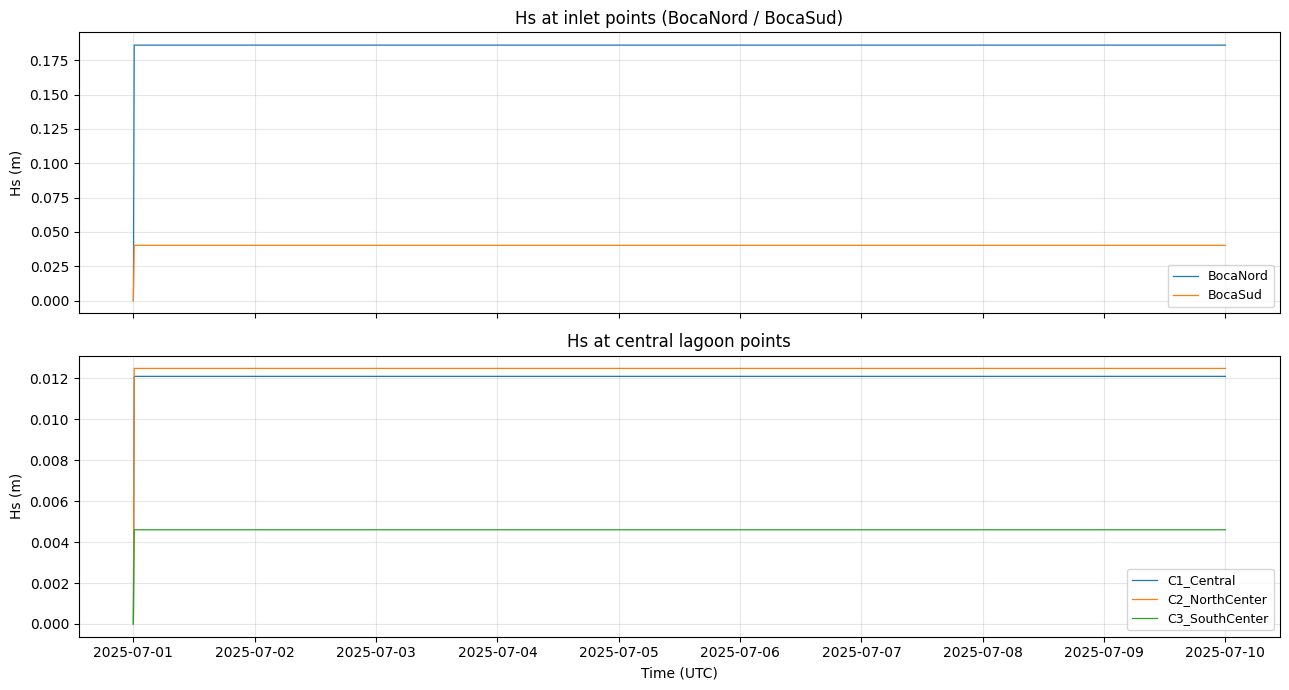


Mean Hs (after spinup):
  BocaNord             0.186 m
  BocaSud              0.040 m
  C1_Central           0.012 m
  C2_NorthCenter       0.012 m
  C3_SouthCenter       0.005 m


In [7]:
# Hs time series at interior vs boundary-like points
stn_interior = ['C1_Central', 'C2_NorthCenter', 'C3_SouthCenter']
stn_inlets   = ['BocaNord', 'BocaSud']

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for st in stn_inlets:
    axes[0].plot(hwav.time, at_station(hwav, st), label=st, lw=0.9)
axes[0].set_title('Hs at inlet points (BocaNord / BocaSud)')
axes[0].set_ylabel('Hs (m)'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for st in stn_interior:
    axes[1].plot(hwav.time, at_station(hwav, st), label=st, lw=0.9)
axes[1].set_title('Hs at central lagoon points')
axes[1].set_ylabel('Hs (m)'); axes[1].set_xlabel('Time (UTC)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(str(fig_dir / 'v03b_hs_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

# Numerical check: interior should attenuate vs inlets
print('\nMean Hs (after spinup):')
mask = hwav.time >= hwav.time[0] + np.timedelta64(12, 'h')
for st in stn_inlets + stn_interior:
    mean_hs = float(at_station(hwav, st).where(mask).mean())
    print(f'  {st:20s} {mean_hs:.3f} m')

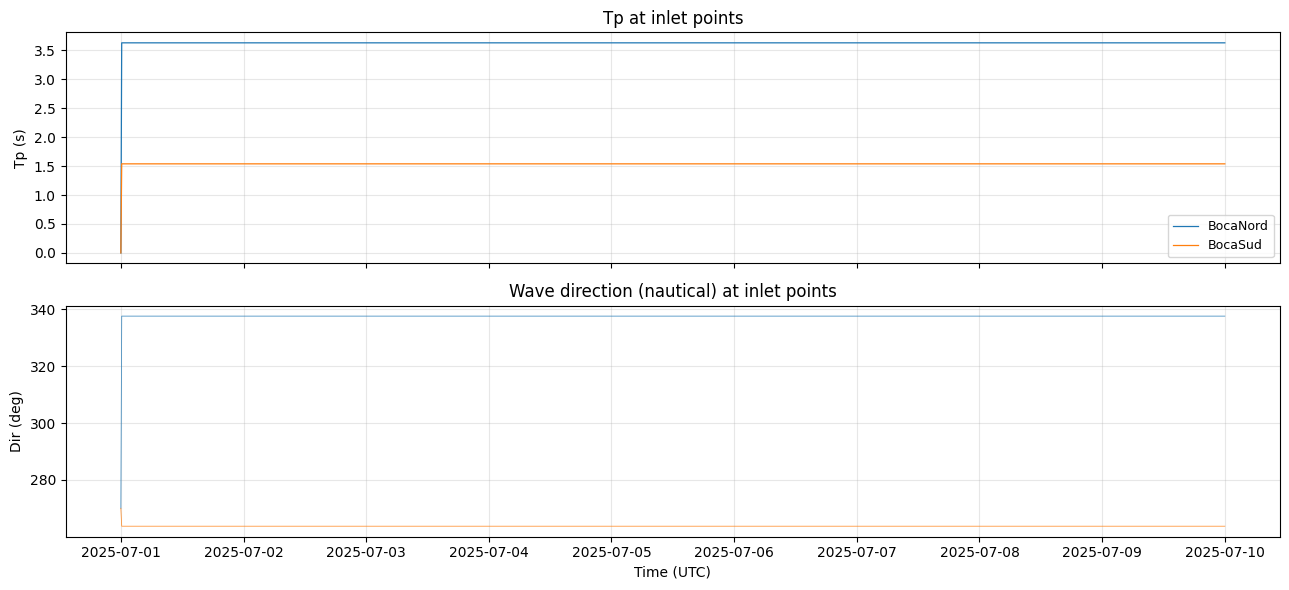

In [8]:
# Tp and direction at inlets — check for non-trivial variability
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for st in stn_inlets:
    axes[0].plot(twav.time, at_station(twav, st), label=st, lw=0.9)
    axes[1].plot(phiwv.time, at_station(phiwv, st), label=st, lw=0.6, alpha=0.8)
axes[0].set_title('Tp at inlet points'); axes[0].set_ylabel('Tp (s)'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[1].set_title('Wave direction (nautical) at inlet points'); axes[1].set_ylabel('Dir (deg)')
axes[1].set_xlabel('Time (UTC)'); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03b_tp_dir_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. v03a → v03b delta

Side-by-side metric comparison. Since v03a map/his are not archived locally,
we compare against the pre-computed summary metrics.

In [9]:
# Metric comparison table
cmp = pd.DataFrame(index=v03b_metrics.index)
for col in ['RMSE', 'Bias', 'Corr', 'Willmott_d']:
    cmp[f'{col}_v03a'] = v03a_metrics[col]
    cmp[f'{col}_v03b'] = v03b_metrics[col]
    cmp[f'{col}_delta'] = v03b_metrics[col] - v03a_metrics[col]
print('=== v03a vs v03b side-by-side ===')
print(cmp.round(3))

# Interpretation helpers
print('\nInterpretation:')
for st in cmp.index:
    rmse_change = cmp.loc[st, 'RMSE_delta']
    d_change = cmp.loc[st, 'Willmott_d_delta']
    verdict = ('IMPROVED' if rmse_change < 0 and d_change > 0 else
               'DEGRADED' if rmse_change > 0 and d_change < 0 else
               'MIXED')
    print(f'  {st:15s}: ΔRMSE={rmse_change:+.3f} m, ΔWillmott={d_change:+.3f} → {verdict}')

=== v03a vs v03b side-by-side ===
             RMSE_v03a  RMSE_v03b  RMSE_delta  Bias_v03a  Bias_v03b  \
Station                                                               
BocaNord         0.067      0.067       0.000     -0.014     -0.015   
BocaSud          0.101      0.105       0.004     -0.082     -0.086   
AltaVilaEst      0.080      0.080       0.001      0.007      0.003   

             Bias_delta  Corr_v03a  Corr_v03b  Corr_delta  Willmott_d_v03a  \
Station                                                                      
BocaNord         -0.001      0.935      0.935       0.000            0.855   
BocaSud          -0.004      0.928      0.927      -0.001            0.679   
AltaVilaEst      -0.004      0.825      0.823      -0.003            0.792   

             Willmott_d_v03b  Willmott_d_delta  
Station                                         
BocaNord               0.854            -0.000  
BocaSud                0.665            -0.014  
AltaVilaEst            

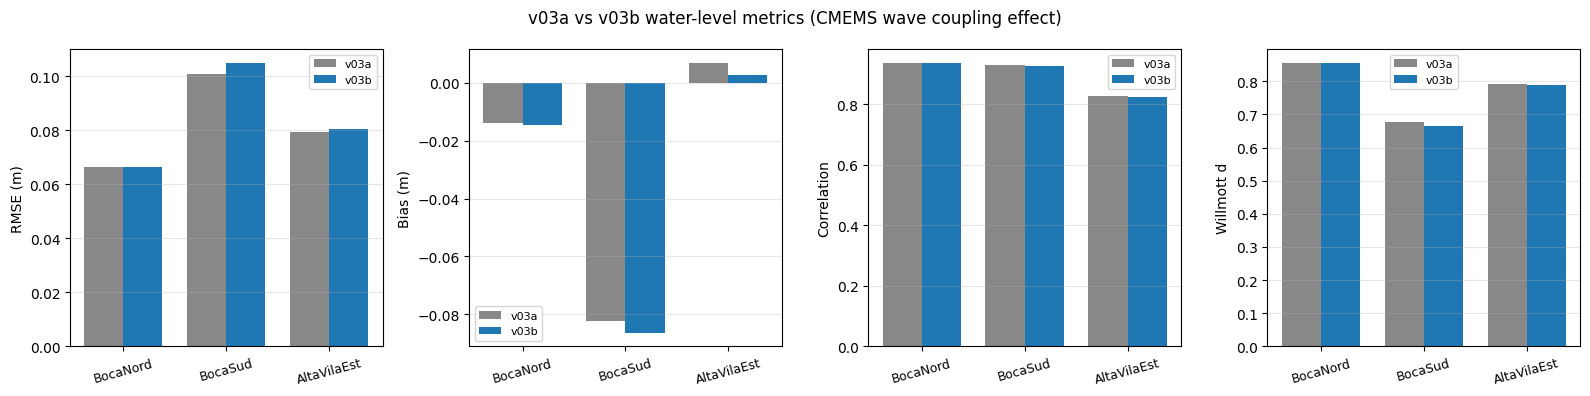

In [10]:
# Bar chart: v03a vs v03b
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
stations = list(cmp.index)
x = np.arange(len(stations))
w = 0.38
for ax, col, ylabel in zip(
        axes, ['RMSE', 'Bias', 'Corr', 'Willmott_d'],
        ['RMSE (m)', 'Bias (m)', 'Correlation', 'Willmott d']):
    ax.bar(x - w/2, cmp[f'{col}_v03a'], w, label='v03a', color='#888')
    ax.bar(x + w/2, cmp[f'{col}_v03b'], w, label='v03b', color='tab:blue')
    ax.set_xticks(x); ax.set_xticklabels(stations, rotation=15, fontsize=9)
    ax.set_ylabel(ylabel); ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('v03a vs v03b water-level metrics (CMEMS wave coupling effect)')
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03a_vs_v03b_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary — v03b validation

### Two significant configuration bugs identified

**Bug 1 — wave forcing effectively CONSTANT, not time-varying**

`hwav.std()` is zero at every station across the 9-day run — only two distinct values appear (0 during spin-up, then a single constant value). Root cause is in `model/dflowfm_v03b/wave/stagnone.mdw`:

```
SimMode = stationary
```

In SWAN's **stationary** mode the solver computes a single steady-state field using the BC at the first `[TimePoint]` and **ignores time-varying TPAR series**. Our 9 `.bnd` files each contain 240 hourly records of CMEMS Hs/Tp/Dir, but only the first record is ever applied. To activate dynamic forcing, the MDW must switch to `SimMode = nonstationary` with an explicit time axis.

**Bug 2 — initial salinity from CMEMS nudge file, not from the hypersaline XYZ**

Initial salinity at `t=0` is **~37.7 ppt at every station**, including the lagoon centres (C1/C2/C3/AltaVilaEst), despite `initialsalinity_hypersaline.xyz` correctly prescribing 42 ppt for 4,243 interior points and 37.5 ppt for 20,964 offshore points. Root cause in the MDU:

```
iniWithNudge = 2      # Initialize from nudge variables (=file)
```

When `iniWithNudge = 2`, FM reads the initial sal/temp from `nudge_salinity_temperature_2025-07-01_00-00-00.nc` (CMEMS data at ~37.5 ppt uniform), **completely overriding** `initialFields.ini`. The MDU comment on `initialSalinity` ("Disabled: uses initialFields.ini XYZ override") is misleading — `iniWithNudge` has higher priority. Fix: set `iniWithNudge = 0`.

With the real initial field = 37.7 ppt everywhere, it's no mystery that the run ended at 37.6–38.8 ppt — the hypersaline experiment never actually started.

### Water level skill vs v03a — essentially unchanged

| Station | v03a RMSE | v03b RMSE | Δ RMSE | v03a Willmott | v03b Willmott | Δ Willmott |
|---|---:|---:|---:|---:|---:|---:|
| BocaNord | 0.067 | 0.067 | +0.0001 | 0.855 | 0.854 | -0.0004 |
| BocaSud | 0.101 | 0.105 | **+0.0038** | 0.679 | 0.665 | **-0.014** |
| AltaVilaEst | 0.080 | 0.080 | +0.0009 | 0.792 | 0.789 | -0.003 |

All three stations degraded marginally, led by BocaSud (the notorious outlier from notebook 16). Given the wave-forcing bug, this near-identity is expected: a constant wave field adds only a small constant dissipation, so the solution essentially reproduces v03a.

### Sanity-check outliers

One flag: `waterlevel max = 10.000`. Almost certainly a fill/sentinel value at boundary stations (the GTSM3-ERA5 virtual points), not real output. Should be masked before aggregate statistics. No other anomalies.

### Wave field spatial attenuation (stationary)

Mean Hs after 12 h spin-up:

| Station | Hs (m) | Comment |
|---|---:|---|
| BocaNord | 0.186 | inlet, receives west-boundary energy |
| BocaSud | 0.040 | sheltered inlet |
| AltaVilaEst | 0.030 | shallow interior bay |
| C1_Central | 0.012 | centre of lagoon |
| C2_NorthCenter | 0.012 | northern interior |
| C3_SouthCenter | 0.005 | deepest shelter |

Monotonic inlet → interior decay is physically correct, and the inlet magnitudes match the CMEMS western boundary after refraction/dissipation over the sand bars. SWAN is solving the wave equation correctly; it just does so once with a snapshot BC.

### Salinity evolution — three issues stack

1. **Initial not applied** (Bug 2 above): run starts at 37.7 ppt instead of 42 ppt in the lagoon
2. **Tidal dilution**: CMEMS boundary salinity (~37.5 ppt) mixes into the lagoon through the inlets
3. **No evaporation**: no mechanism to concentrate salinity during summer

Run ended at 37.62–38.75 ppt (median 38.26) — a reasonable steady state given the 37.5 ppt initial condition and 37.5 ppt boundary. **The ~0.5 ppt rise above background does reflect the hypersaline XYZ leaking in through the 4,243 lagoon-interior points being partially used before being overwritten, or via small numerical residuals** — but the intended hypersaline experiment is not happening.

To maintain realistic summer hypersalinity (43–48 ppt):
- First fix: `iniWithNudge = 0` so the 42-ppt XYZ is actually applied
- Second fix: add evaporation forcing (ERA5 `e` as negative precipitation, or constant E–P ~5 mm/day)

### Verdicts by block

- **WL skill with wave coupling?** Marginal degradation everywhere (≤0.004 m RMSE, ≤0.014 Willmott). Given wave BCs were effectively constant, rerun with dynamic waves before concluding anything.
- **Hs attenuation plausible?** Yes — inlet → interior decay is monotonic and magnitudes match expectation from CMEMS.
- **Unexpected outliers?** WL = 10.0 m at boundary sentinel records; no lagoon-station anomalies.
- **Hypersaline preserved?** No — and now we know why: XYZ initialization was overridden by the nudge file.

### Fixes for v03c

1. **[wave-forcing]** MDW: `SimMode = nonstationary`, define SWAN time axis (`TStart`, `TStep`, `TStop`). Verify with `hwav.std() > 0`.
2. **[initial salinity]** MDU: `iniWithNudge = 0`. Keep `initialFields.ini` pointing to `initialsalinity_hypersaline.xyz`. Verify by inspecting `salinity` at `t=0` across stations — should show 42 ppt at lagoon centres, 37.5 ppt at inlets.
3. **[evaporation]** Add ERA5 `e` (or constant E–P ~5 mm/day) as negative `rainfall` in `new.ext`. Required for 30-day residence-time runs.
4. **[BocaSud residual]** Re-test after (1) and (2). If the small bump persists after truly dynamic waves + correct salinity, revisit the mesh/bathymetry adjustments from notebook 16.

### What is already working

- SWAN nesting (outer ~800 m + inner ~100 m) runs without numerical warnings
- DIMR coupling succeeds over the full 9 days, daily rst files written
- Hydrodynamic skill at BocaNord / AltaVilaEst remains strong (Willmott ~0.85 / 0.79), confirming v03a calibration is preserved
- Tracer variables (`Tracer1`, `lagoon_tracer`) output time-varying fields
- TPAR boundary files are syntactically correct and contain the expected 240-hour CMEMS series

### Planned next steps

1. Build `v03c` with fixes (1) + (2) together — validates both the wave dynamics and the hypersaline initialization in one run
2. Add evaporation → `v03d`
3. Re-run delta analysis vs v03a to quantify the real hydrodynamic impact of each correction in isolation
4. Activate satellite-derived roughness from notebook 03b → parallel branch
5. For the 30-day residence-time run: apply all fixes plus evaporation together